In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from keras.models import load_model
sys.path.append(os.path.abspath(os.path.join(os.path.dirname('variational_ae.py'), '..')))
sys.path.append(os.path.abspath(os.path.join(os.path.dirname('encoder.py'), '..')))
sys.path.append(os.path.abspath(os.path.join(os.path.dirname('decoder.py'), '..')))
from variational_ae import VariationalAutoencoder
from encoder import EncoderBuilder, Sampling
from decoder import DecoderBuilder
from tensorflow.python.keras.losses import MeanSquaredError
from tensorflow.keras.datasets import mnist
import h5py

2025-08-16 18:21:58.299854: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-16 18:21:58.444087: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-16 18:22:01.061693: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:

def select_images(images, labels, num_images=10):
    sample_images_index = np.random.choice(range(len(images)), num_images)
    sample_images = images[sample_images_index]
    sample_labels = labels[sample_images_index]
    return sample_images, sample_labels


def plot_reconstructed_images(images, reconstructed_images):
    fig = plt.figure(figsize=(10, 3))
    num_images = len(images)
    for i, (image, reconstructed_image) in enumerate(zip(images, reconstructed_images)):
        image = image.squeeze()
        ax = fig.add_subplot(2, num_images, i + 1)
        ax.axis("off")
        ax.imshow(image, cmap="gray_r")
        reconstructed_image = reconstructed_image.squeeze()
        ax = fig.add_subplot(2, num_images, i + num_images + 1)
        ax.axis("off")
        ax.imshow(reconstructed_image, cmap="gray_r")
    plt.show()


def plot_images_encoded_in_latent_space(latent_representations, sample_labels):
    plt.figure(figsize=(7, 5))
    plt.scatter(latent_representations[:, 0],
                latent_representations[:, 1],
                cmap="rainbow",
                c=sample_labels,
                alpha=0.5,
                s=2)
    plt.colorbar()
    plt.show()

In [3]:
full_model = load_model("/home/chua/projects/Autoencoder Notes/Interpretable Sound Generation/initial_full_vae_log_mel_spec.keras",
    custom_objects={
        "VariationalAutoencoder": VariationalAutoencoder,
        "Encoder": EncoderBuilder,
        "Decoder": DecoderBuilder,
        "Sampling" : Sampling
    })
encoder_model = load_model("/home/chua/projects/Autoencoder Notes/Interpretable Sound Generation/initial_encoder_vae_log_mel_spec.keras",
    custom_objects={
        "Sampling" : Sampling
    })
decoder_model = load_model("/home/chua/projects/Autoencoder Notes/Interpretable Sound Generation/initial_decoder_vae_log_mel_spec.keras")

I0000 00:00:1755339817.912970   21277 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9711 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


In [4]:
with h5py.File('Dataset/log_mel_spec_data_dataset.h5', 'r') as h5f:
    log_mel_spec_data_train = h5f['train'][:]
    log_melspec_data_labels = h5f['label'][:]

In [ ]:
num_sample_to_show = 10
sample_spec_vector, sample_labels = select_images(log_mel_spec_data_train, log_melspec_data_labels, num_sample_to_show)

In [ ]:
mu, log_var, latent_representations = encoder_model.predict(sample_images)
reconstructed_images = decoder_model.predict(latent_representations)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step


In [8]:
reconstructed_images.shape

(10, 128, 64, 1)

In [9]:
latent_representations.shape

(10, 128)

In [10]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap

In [68]:
num_sample_to_show = len(log_mel_spec_data_train)
sample_spec_vector, sample_labels = select_images(log_mel_spec_data_train, log_melspec_data_labels, num_sample_to_show)
mu, log_var, latent_representations = encoder_model.predict(sample_spec_vector)

938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step


PCA

In [69]:
latent_representations.shape

(30000, 128)

In [70]:
pca = PCA(n_components=2)
latent_representations_pca = pca.fit_transform(latent_representations)

In [71]:
x = latent_representations_pca[:, 0] # 1st principal component (PC1): the direction that explains the most variance in the data. X - AXIS
y = latent_representations_pca[:, 1] # 2nd principal component (PC2): the direction orthogonal to PC1 that explains the next highest variance. Y - AXIS

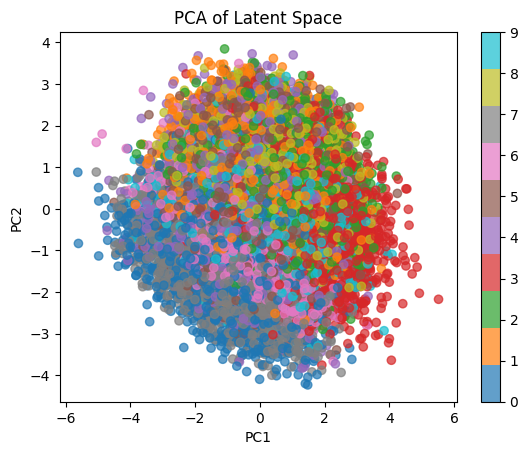

In [72]:
plt.scatter(x, y, c=sample_labels, cmap='tab10', alpha=0.7)
plt.title("PCA of Latent Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar()
plt.show()

Shows that the data in latent space dimension is really a non linear since PCA cannot produce proper output

t-SNE
https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html

In [73]:
tsne = TSNE(n_components=2, perplexity=50, random_state=42)
# The perplexity is related to the number of nearest neighbors that is used in other manifold learning algorithms.
# Larger datasets usually require a larger perplexity. Consider selecting a value between 5 and 50.
# Different values can result in significantly different results.
# The perplexity must be less than the number of samples.
latent_representations_tsne = tsne.fit_transform(latent_representations)

In [74]:
x = latent_representations_tsne[:, 0] # X - Axis!
y = latent_representations_tsne[:, 1] # Y - Axis!

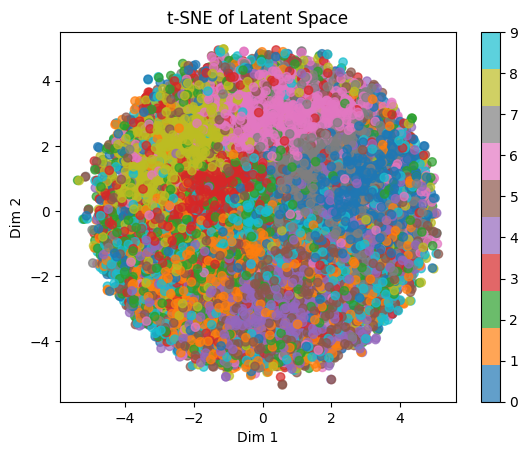

In [75]:
plt.scatter(x, y, c=sample_labels, cmap='tab10', alpha=0.7)
plt.title("t-SNE of Latent Space")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.colorbar()
plt.show()

UMAP
https://umap-learn.readthedocs.io/en/latest/parameters.html

In [82]:
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=20, min_dist=0.5)
latent_representations_umap = reducer.fit_transform(latent_representations)

/home/chua/projects/tf217/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [83]:
x = latent_representations_umap[:, 0]
y = latent_representations_umap[:, 1]

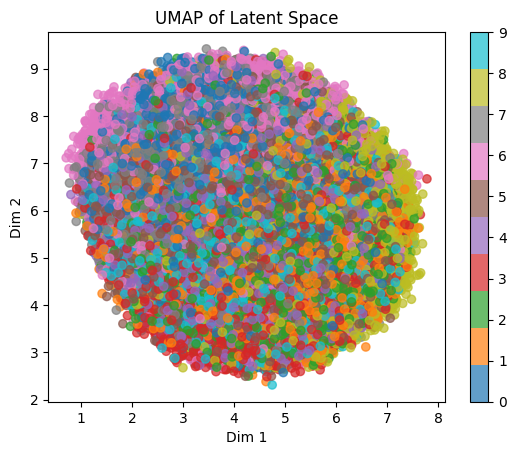

In [84]:
plt.scatter(x, y, c=sample_labels, cmap='tab10', alpha=0.7)
plt.title("UMAP of Latent Space")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.colorbar()
plt.show()

PCA and t-SNE

In [130]:
pca = PCA(n_components=30).fit_transform(latent_representations)

In [131]:
z_2d_tsne = TSNE(n_components=2, perplexity=50).fit_transform(pca)

In [132]:
x = z_2d_tsne[:, 0]
y = z_2d_tsne[:, 1]

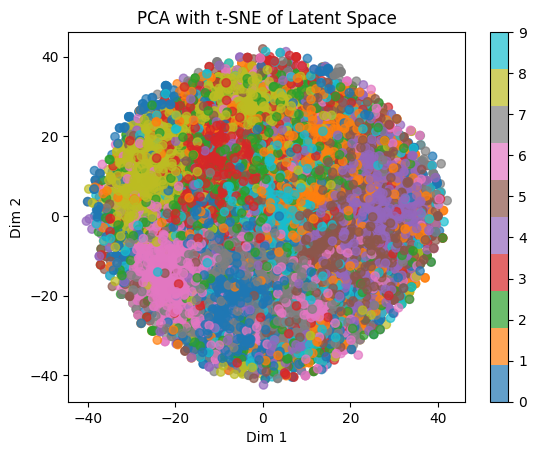

In [133]:
plt.scatter(x, y, c=sample_labels, cmap='tab10', alpha=0.7)
plt.title("PCA with t-SNE of Latent Space")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.colorbar()
plt.show()

In [134]:
z2d_umap = umap.UMAP(n_components=2, n_neighbors=100, min_dist=0.99).fit_transform(pca)

In [135]:
x = z2d_umap[:, 0]
y = z2d_umap[:, 1]

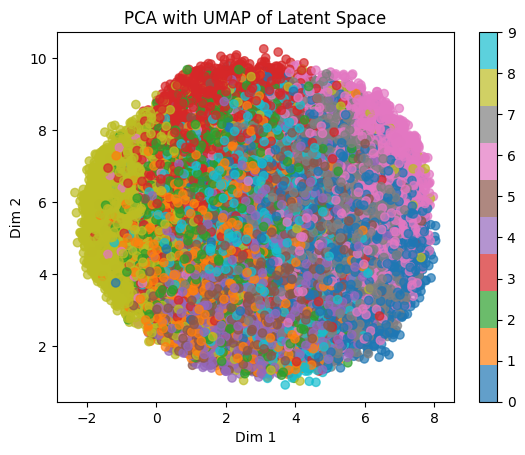

In [136]:
plt.scatter(x, y, c=sample_labels, cmap='tab10', alpha=0.7)
plt.title("PCA with UMAP of Latent Space")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.colorbar()
plt.show()

In [137]:
correlation = np.corrcoef(z_2d_tsne.flatten(), z2d_umap.flatten())[0, 1]
print(f"Pearson correlation: {correlation:.4f}")

Pearson correlation: 0.0893
